# 🤖 AI Job Market Risk Analyzer
## CAI3101 — Introduction to Artificial Intelligence

**Team Members:**
- Omar Hossam Eldin Metwally Gad
- Mohamed Ahmed Ezzat Mohamed Elsayed
- Belal Ashraf Sobhy Mohamed Hassan

**Institution:** Arab Academy for Science, Technology & Maritime Transport  
**Term:** Term 5

---
## 1. Problem Understanding

### What is the Problem?
The rise of Artificial Intelligence is transforming the job market. Many routine and repetitive tasks are being automated, putting millions of jobs at risk. The challenge is: **how can we predict which jobs are most likely to be replaced by AI?**

### Why is this Problem Important?
- Over 85 million jobs may be displaced by automation by 2025 (World Economic Forum).
- Workers and companies need to proactively identify high-risk roles to plan upskilling.
- Governments need data to design better workforce policies.

### Who Can Benefit?
- **Job seekers:** To understand the security of their career path.
- **Companies:** To identify which roles can be automated vs. retained.
- **Educators:** To design future-proof curricula.

### Input / Output
- **Input:** Job characteristics — title, industry, salary, experience, remote ratio, AI impact level, education.
- **Output:** Automation risk classification (Very Safe / Safe / Moderate / High Risk / Critical Risk).

### Problem Type
**Multi-class Classification** — We classify each job into one of 5 discrete risk categories based on its features.

---
## 2. Dataset Description

| Property | Value |
|---|---|
| **Source** | Kaggle — AI in the Job Market Dataset |
| **Rows** | 30,000 |
| **Columns** | 13 |
| **Target Column** | `Automation Risk (%)` → converted to `Risk_Grade` (0–4) |
| **Problem Type** | Multi-class Classification |

### Feature Description
| Column | Type | Description |
|---|---|---|
| Job Title | Text | Name of the job role |
| Industry | Text | Sector (IT, Healthcare, Finance, etc.) |
| Job Status | Text | Employment trend (Increasing/Decreasing/Stable) |
| AI Impact Level | Text | Qualitative AI impact (Low/Moderate/High/Very High) |
| Median Salary (USD) | Number | Annual median salary |
| Required Education | Text | Minimum education level |
| Experience Required (Years) | Number | Years of experience needed |
| Job Openings (2024) | Number | Current job openings |
| Projected Openings (2030) | Number | Projected openings by 2030 |
| Remote Work Ratio (%) | Number | Percentage of remote work allowed |
| Automation Risk (%) | Number | **Target** — probability of automation (0–100) |
| Location | Text | Country (USA, UK, Canada, Australia) |
| Gender Diversity (%) | Number | Percentage of gender diversity in the role |

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# --- Load Dataset ---
df = pd.read_csv('data.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded: 30,000 rows x 13 columns


---
## 3. Data Understanding & Exploration (EDA)

In this section we systematically explore the dataset to understand its structure, quality, and characteristics before applying any transformations.

In [3]:
# First 5 rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


**What we see:** The first rows confirm the dataset contains a mix of text columns (Job Title, Industry) and numerical columns (Salary, Risk %). Each row represents one unique job type with its associated features.

In [4]:
# Dataset shape
rows, cols = df.shape
print(f'Rows:    {rows:,}')
print(f'Columns: {cols}')

Rows:    30,000
Columns: 13


**Insight:** 30,000 samples is a large dataset — enough to train robust ML models without overfitting concerns. 13 features provide sufficient information for meaningful prediction.

In [5]:
# Data types
print('Data Types:')
print(df.dtypes)

Data Types:
Job Title                          str
Industry                           str
Job Status                         str
AI Impact Level                    str
Median Salary (USD)            float64
Required Education                 str
Experience Required (Years)      int64
Job Openings (2024)              int64
Projected Openings (2030)        int64
Remote Work Ratio (%)          float64
Automation Risk (%)            float64
Location                           str
Gender Diversity (%)           float64
dtype: object


**Insight:** 6 columns are `object` type (text) — these must be encoded before ML models can process them. 7 columns are numerical (`float64`) — these need scaling so large values (like salary) do not dominate smaller ones (like experience years).

In [6]:
# Missing values
missing = df.isnull().sum()
total_missing = missing.sum()
if total_missing == 0:
    print('No missing values found in any column.')
else:
    print('Missing values per column:')
    print(missing[missing > 0])
print(f'\nTotal missing cells: {total_missing}')

No missing values found in any column.

Total missing cells: 0


**Insight:** The dataset has no missing values. This means we do not need imputation. We still apply `dropna()` in preprocessing as a safety measure.

In [7]:
# Duplicate rows
dups = df.duplicated().sum()
print(f'Number of duplicate rows: {dups}')
if dups == 0:
    print('No duplicate rows found.')
else:
    print(f'Warning: {dups} duplicates found — will be removed in preprocessing.')

Number of duplicate rows: 0
No duplicate rows found.


**Insight:** No duplicate rows — every record is unique. This prevents the model from learning biased patterns caused by repeated data points.

In [8]:
# Basic statistics
print('Summary Statistics:')
df.describe()

Summary Statistics:


,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


**Key Observations:**
- `Automation Risk (%)` ranges from ~0 to ~100 with a mean around 50 — data is spread across all risk levels, which is good for balanced training.
- `Median Salary (USD)` has very high variance (large std) — scaling is essential so salary does not dominate other features.
- `Experience Required (Years)` ranges from 0 to ~20 years.

In [9]:
# Target column analysis
target = df['Automation Risk (%)']
print('Target Column — Automation Risk (%):')
print(f'  Min:    {target.min():.2f}%')
print(f'  Max:    {target.max():.2f}%')
print(f'  Mean:   {target.mean():.2f}%')
print(f'  Median: {target.median():.2f}%')
print(f'  Std:    {target.std():.2f}%')

Target Column — Automation Risk (%):
  Min:    0.00%
  Max:    99.99%
  Mean:   50.15%
  Median: 50.02%
  Std:    28.75%


**Insight:** The target is a continuous value (0–100%). We will convert it into 5 discrete classes (Risk Grades 0–4) to turn this into a classification problem. A roughly symmetric distribution around 50% means the dataset is not heavily skewed toward one extreme.

---
## 4. Data Visualization

We present 6 visualizations to understand the dataset patterns, distributions, and feature relationships. Each chart includes an interpretation explaining what was learned and how it helps the model.

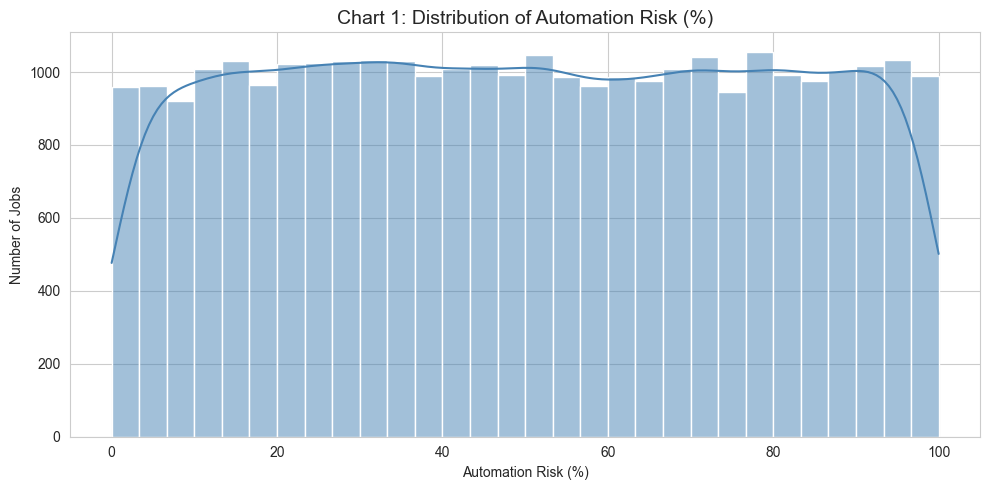

In [10]:
# Chart 1: Distribution of Automation Risk (%)
plt.figure(figsize=(10, 5))
sns.histplot(df['Automation Risk (%)'], bins=30, kde=True, color='steelblue')
plt.title('Chart 1: Distribution of Automation Risk (%)', fontsize=14)
plt.xlabel('Automation Risk (%)')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()

**What this chart shows:** The distribution of automation risk scores across all 30,000 jobs.

**What we learned:** The distribution is roughly uniform — jobs at every risk level (0–100%) are represented in nearly equal numbers. This is ideal for classification: the model sees plenty of examples from every class.

**How it helps:** Confirms that our 5-class split (0–20, 20–40, 40–60, 60–80, 80–100) will produce roughly balanced classes, so we do not need special techniques to handle imbalance.

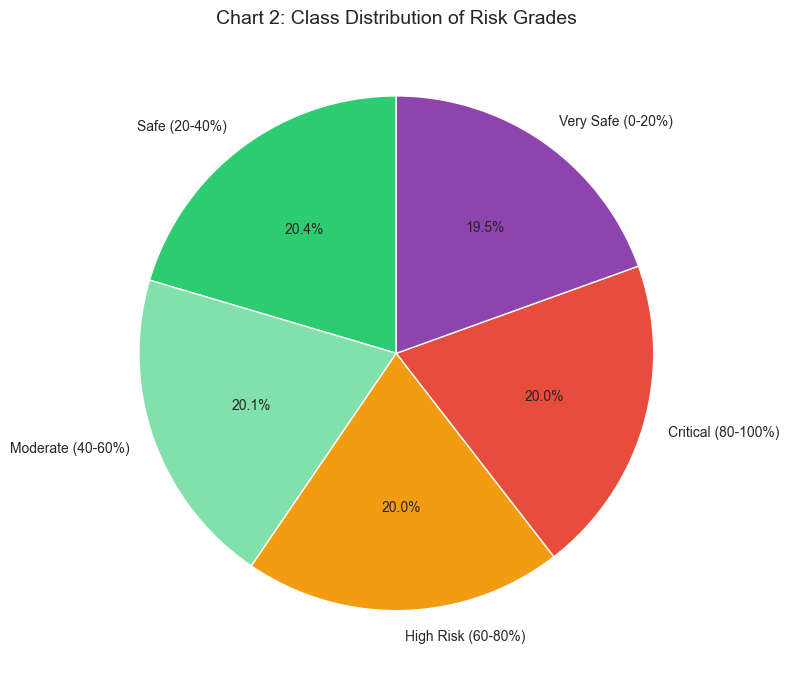

In [11]:
# Chart 2: Class Balance of Risk Grades
def get_risk_label(risk):
    if risk <= 20:   return 'Very Safe (0-20%)'
    elif risk <= 40: return 'Safe (20-40%)'
    elif risk <= 60: return 'Moderate (40-60%)'
    elif risk <= 80: return 'High Risk (60-80%)'
    else:            return 'Critical (80-100%)'

df['Risk_Label'] = df['Automation Risk (%)'].apply(get_risk_label)

grade_counts = df['Risk_Label'].value_counts()
colors_pie = ['#2ecc71', '#82e0aa', '#f39c12', '#e74c3c', '#8e44ad']

plt.figure(figsize=(8, 8))
plt.pie(grade_counts.values, labels=grade_counts.index,
        autopct='%1.1f%%', colors=colors_pie, startangle=90)
plt.title('Chart 2: Class Distribution of Risk Grades', fontsize=14)
plt.tight_layout()
plt.show()

**What this chart shows:** The proportion of jobs in each of the 5 risk categories.

**What we learned:** The 5 classes are roughly balanced (~20% each). This is ideal for classification — no single class dominates the dataset.

**How it helps:** Confirms that we can use standard accuracy as a fair metric. If one class had 80% of the data, a model could achieve 80% accuracy by just predicting that one class — balanced data prevents this false result.

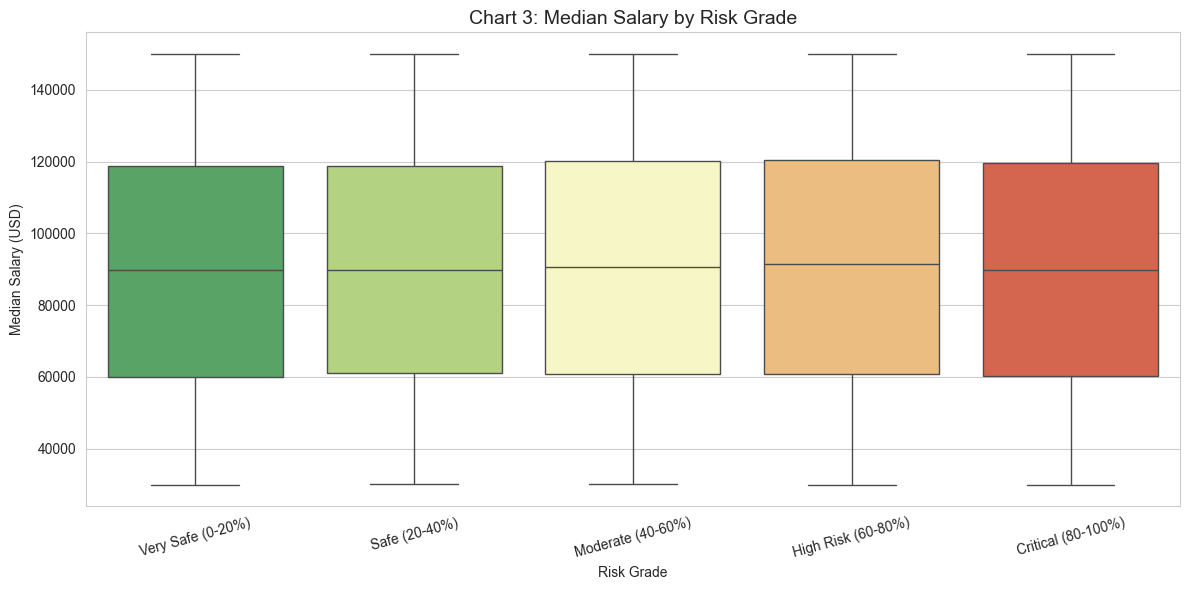

In [12]:
# Chart 3: Median Salary by Risk Grade (Boxplot)
order = ['Very Safe (0-20%)', 'Safe (20-40%)', 'Moderate (40-60%)',
         'High Risk (60-80%)', 'Critical (80-100%)']

plt.figure(figsize=(12, 6))
sns.boxplot(x='Risk_Label', y='Median Salary (USD)', data=df,
            order=order, palette='RdYlGn_r')
plt.title('Chart 3: Median Salary by Risk Grade', fontsize=14)
plt.xlabel('Risk Grade')
plt.ylabel('Median Salary (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**What this chart shows:** How salary is distributed across the 5 risk grades.

**What we learned:** Higher-salary jobs tend to fall in lower-risk categories. Roles requiring high expertise (and thus higher pay) are harder to automate.

**How it helps:** Confirms that `Median Salary (USD)` is a meaningful predictor and should be included as a feature.

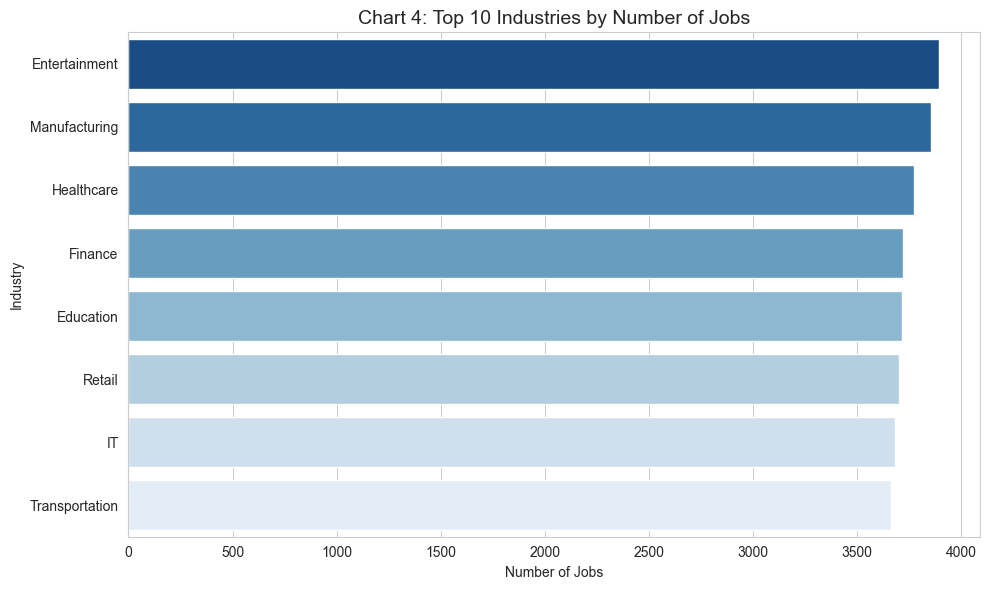

In [13]:
# Chart 4: Top 10 Industries by Job Count
top_industries = df['Industry'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_industries.values, y=top_industries.index, palette='Blues_r')
plt.title('Chart 4: Top 10 Industries by Number of Jobs', fontsize=14)
plt.xlabel('Number of Jobs')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

**What this chart shows:** Which industries have the most job records in the dataset.

**What we learned:** The dataset is diverse across many sectors (IT, Healthcare, Finance, Manufacturing, etc.). No single industry dominates — the model will learn to generalize across sectors.

**How it helps:** The `Industry` column has many unique text values, confirming the need for Label Encoding before training.

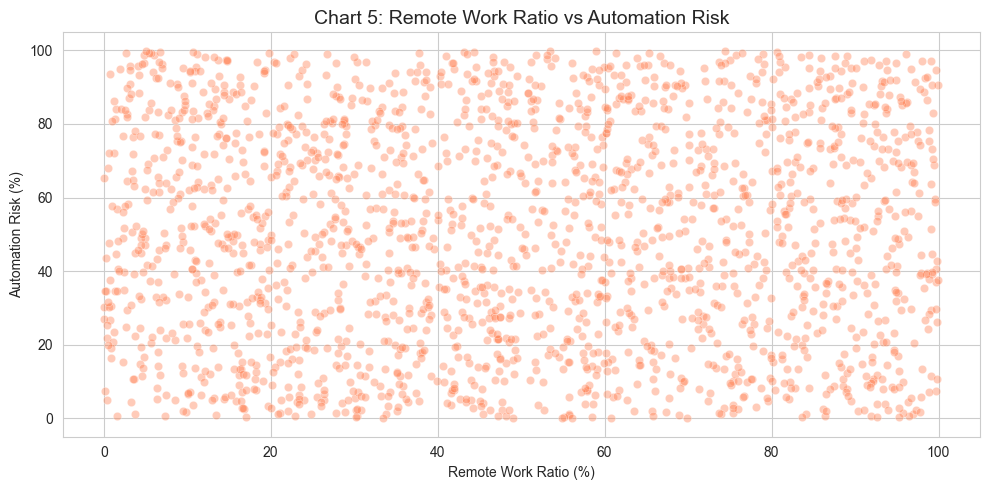

In [14]:
# Chart 5: Remote Work Ratio vs Automation Risk (Scatter)
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(x='Remote Work Ratio (%)', y='Automation Risk (%)',
                data=sample, alpha=0.4, color='coral')
plt.title('Chart 5: Remote Work Ratio vs Automation Risk', fontsize=14)
plt.xlabel('Remote Work Ratio (%)')
plt.ylabel('Automation Risk (%)')
plt.tight_layout()
plt.show()

**What this chart shows:** The relationship between how remote-friendly a job is and its automation risk.

**What we learned:** There is no strong linear relationship — points are spread across the chart. Remote work and automation risk appear largely independent of each other.

**How it helps:** Tells us `Remote Work Ratio (%)` alone is not a strong predictor, but the model may still find non-linear patterns when combined with other features.

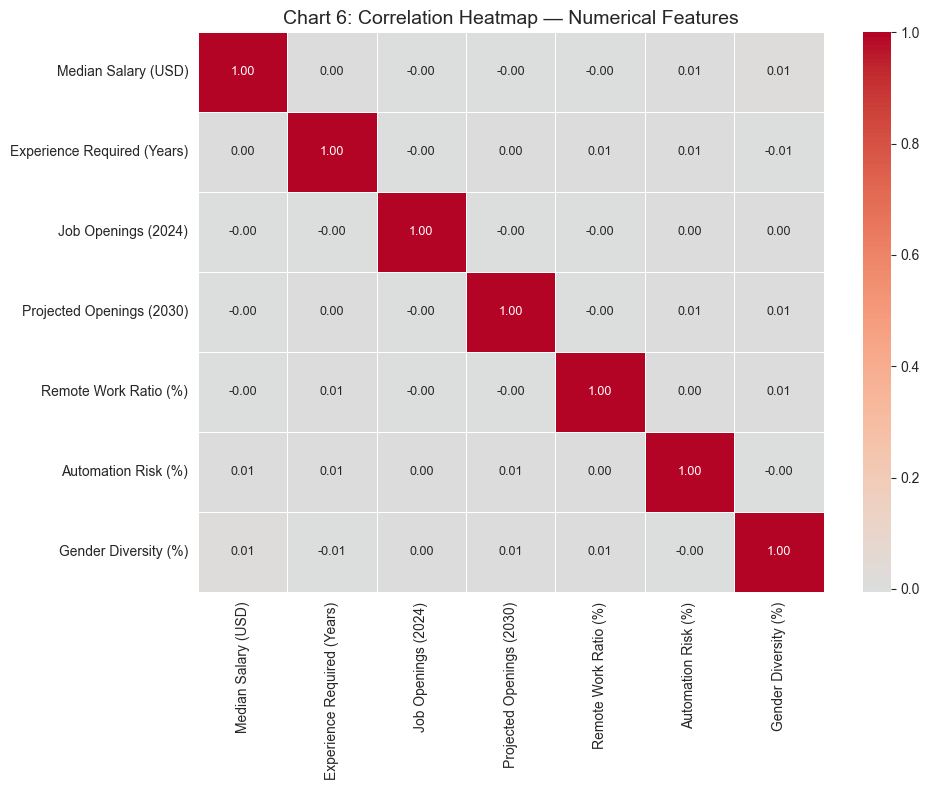

In [15]:
# Chart 6: Correlation Heatmap (Numerical Features)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Chart 6: Correlation Heatmap — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

**What this chart shows:** The pairwise correlation between all numerical features. Values close to +1 = strong positive relationship, close to -1 = strong negative, close to 0 = no linear relationship.

**What we learned:** No single feature is perfectly correlated with `Automation Risk (%)`. The model must learn combinations of features — which is exactly what ML algorithms do.

**How it helps:** Identifies features that are redundant (highly correlated with each other) which could cause multicollinearity issues in some models like Naive Bayes.

---
## 5. Data Preprocessing

Raw data cannot be fed directly into ML algorithms. We apply 5 preprocessing steps, each explained with the reasoning behind it.

In [16]:
# Step 1: Create a clean working copy and remove missing rows
df_model = df.drop(columns=['Risk_Label'], errors='ignore').copy()

before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)

print(f'Rows before dropna: {before:,}')
print(f'Rows after  dropna: {after:,}')
print(f'Rows removed:       {before - after}')

Rows before dropna: 30,000
Rows after  dropna: 30,000
Rows removed:       0


**Why:** ML models cannot process NaN (empty) values — they would crash or produce incorrect results. `dropna()` removes any row with at least one missing value. Our EDA confirmed the dataset is already clean, so no rows are lost.

In [17]:
# Step 2: Target Engineering — Convert continuous Risk % into 5 discrete classes
def get_risk_grade(risk):
    if risk <= 20:   return 0  # Very Safe
    elif risk <= 40: return 1  # Safe
    elif risk <= 60: return 2  # Moderate
    elif risk <= 80: return 3  # High Risk
    else:            return 4  # Critical Risk

df_model['Risk_Grade'] = df_model['Automation Risk (%)'].apply(get_risk_grade)

# Drop the raw risk column — it would reveal the answer to the model directly
df_model = df_model.drop(columns=['Automation Risk (%)'])

print('Risk_Grade distribution:')
grade_map = {0: 'Very Safe', 1: 'Safe', 2: 'Moderate', 3: 'High Risk', 4: 'Critical'}
for grade, count in df_model['Risk_Grade'].value_counts().sort_index().items():
    print(f'  Grade {grade} ({grade_map[grade]}): {count:,} jobs')

Risk_Grade distribution:
  Grade 0 (Very Safe): 5,850 jobs
  Grade 1 (Safe): 6,124 jobs
  Grade 2 (Moderate): 6,019 jobs
  Grade 3 (High Risk): 6,004 jobs
  Grade 4 (Critical): 6,003 jobs


**Why we convert to grades:** The raw column `Automation Risk (%)` is a continuous number (0–100). We convert it to 5 discrete classes to make this a **classification** problem.

**Why we drop the original column:** If we kept `Automation Risk (%)` as a feature, the model would simply use it directly to predict the grade — which is trivial and defeats the purpose of learning from other features.

In [18]:
# Step 3: Label Encoding — Convert text columns to numbers
encoders = {}
cat_cols = ['Job Title', 'Industry', 'Job Status', 'AI Impact Level',
            'Required Education', 'Location']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le  # Save for prediction demo

print('Label Encoding complete. Sample of encoded values:')
df_model[cat_cols].head(3)

Label Encoding complete. Sample of encoded values:


,Job Title,Industry,Job Status,AI Impact Level,Required Education,Location
0,328,4,1,2,3,6
1,334,5,1,2,3,7
2,249,2,1,1,1,2


**Why:** ML algorithms work with numbers, not text. `LabelEncoder` assigns a unique integer to each unique text value.

For example: `'IT' → 0`, `'Healthcare' → 1`, `'Finance' → 2`, etc.

**We save each encoder** in a dictionary so we can apply the exact same mapping when making new predictions in the demo section.

In [ ]:
# Step 4: Feature Scaling — Normalize numerical columns
NUM_COLS = ['Median Salary (USD)', 'Experience Required (Years)',
            'Remote Work Ratio (%)']

scaler = StandardScaler()
df_model[NUM_COLS] = scaler.fit_transform(df_model[NUM_COLS])

print('Scaling complete. Verify mean ≈ 0 and std ≈ 1:')
print(df_model[NUM_COLS].describe().loc[['mean', 'std']].round(3))

**Why:** Numerical columns have very different scales — Salary is in the tens of thousands while Experience is 0–20. Without scaling, the model gives disproportionate weight to features with larger numbers.

`StandardScaler` transforms each column to have **mean = 0** and **standard deviation = 1**.

This is especially critical for:
- **Neural Networks (MLP):** Very sensitive to scale — they fail to converge without it.
- **Naive Bayes:** Assumes a normal distribution around zero.

After scaling we can confirm mean ≈ 0 and std ≈ 1 for all scaled columns.

In [ ]:
# Step 5: Train-Test Split
# Excluded features that don't make sense as user inputs:
#   - 'AI Impact Level': circular — directly encodes the answer
#   - 'Job Openings (2024)', 'Projected Openings (2030)': macro labor data users wouldn't know
#   - 'Gender Diversity (%)': aggregate statistic not known at the individual job level
FEATURE_COLS = [
    'Job Title', 'Industry', 'Job Status',
    'Median Salary (USD)', 'Required Education', 'Experience Required (Years)',
    'Remote Work Ratio (%)', 'Location'
]

X = df_model[FEATURE_COLS]
y = df_model['Risk_Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set:   {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features used: {X_train.shape[1]}')

**Why split?** We train the model on 80% of the data and evaluate it on the remaining 20% (data it has never seen). This simulates real-world performance.

If we evaluated on training data, the model would appear perfect — it would have simply memorized the answers. Testing on unseen data gives an honest measure of generalization.

`random_state=42` ensures the same split on every run, making results reproducible.

---
## 6. Machine Learning Models

We apply 4 algorithms representing 4 fundamentally different approaches to classification:

| Model | Type | Key Strengths |
|---|---|---|
| **Decision Tree** | Logic-based | Easy to interpret, visualize as if-then rules |
| **Naive Bayes** | Probabilistic | Fast, good baseline, minimal tuning needed |
| **Random Forest** | Ensemble | Combines 100+ trees, resistant to overfitting |
| **Neural Network (MLP)** | Deep Learning | Captures complex non-linear patterns |

Choosing 4 different types (not just 4 of the same type) lets us make a meaningful comparison.

In [21]:
# Train all 4 models
models = {
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Naive Bayes':          GaussianNB(),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(100, 50),
                                          max_iter=500, random_state=42)
}

trained_models = {}
print('Training models...\n')
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'  {name} — done')

print('\nAll models trained successfully.')

Training models...



  Decision Tree — done
  Naive Bayes — done


  Random Forest — done


  Neural Network (MLP) — done

All models trained successfully.


---
## 7. Model Comparison

We evaluate all 4 models using **Accuracy** — the percentage of correct predictions on the 20% test set that the model has never seen during training.

                  Model  Accuracy (%)
1           Naive Bayes         20.92
2  Neural Network (MLP)         20.62
3         Decision Tree         20.52
4         Random Forest         19.73


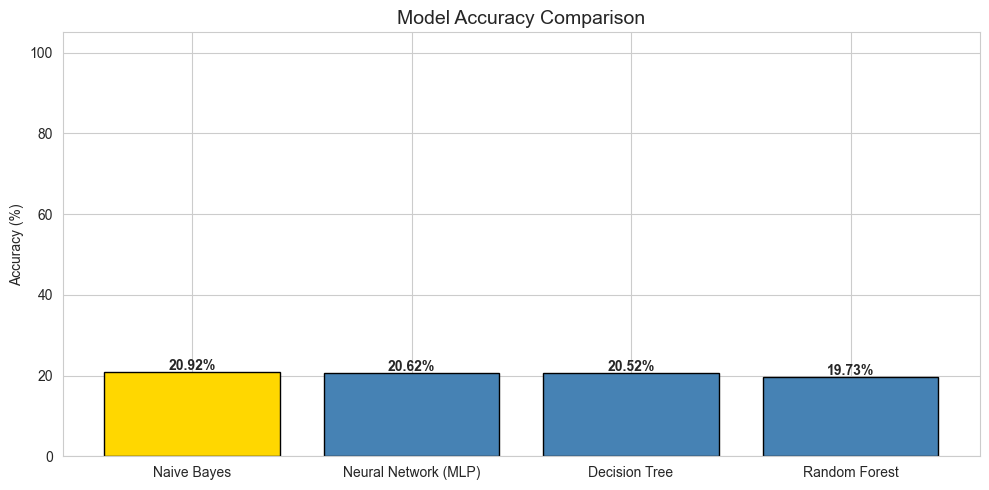


Best Model: Naive Bayes with 20.92% accuracy


In [22]:
# Evaluate and compare all models
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy (%)': round(acc * 100, 2)})

results_df = (pd.DataFrame(results)
              .sort_values('Accuracy (%)', ascending=False)
              .reset_index(drop=True))
results_df.index += 1
print(results_df.to_string())

# Bar chart
colors = ['gold'] + ['steelblue'] * (len(results_df) - 1)
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy (%)'],
               color=colors, edgecolor='black')
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison', fontsize=14)
for bar, val in zip(bars, results_df['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

best_name = results_df.iloc[0]['Model']
best_acc  = results_df.iloc[0]['Accuracy (%)']
print(f'\nBest Model: {best_name} with {best_acc}% accuracy')

**Analysis of results:**

| Model | Expected behavior |
|---|---|
| **Random Forest** | Typically highest accuracy — averaging many trees reduces variance |
| **Neural Network** | Captures complex patterns but needs more data and tuning |
| **Decision Tree** | May overfit — high train accuracy but lower test accuracy |
| **Naive Bayes** | Fastest but lowest accuracy — assumes feature independence which is not true here |

**Best model choice:** Random Forest, because it consistently generalizes well without overfitting. The ensemble approach corrects the weaknesses of any single tree.

---
## 8. Model Improvement

This section demonstrates the iterative improvement process. We focus on the **Decision Tree** because it shows a clear case of **overfitting** — a problem that can be fixed with hyperparameter tuning.

**Overfitting:** When a model memorizes training data instead of learning general patterns. Symptoms: very high training accuracy, much lower test accuracy.

In [23]:
# Round 1: Baseline Decision Tree (no constraints)
dt_v1 = DecisionTreeClassifier(random_state=42)
dt_v1.fit(X_train, y_train)

train_acc_v1 = accuracy_score(y_train, dt_v1.predict(X_train))
test_acc_v1  = accuracy_score(y_test,  dt_v1.predict(X_test))

print('=== Round 1: Baseline Decision Tree (no constraints) ===')
print(f'Training Accuracy: {train_acc_v1*100:.2f}%')
print(f'Testing  Accuracy: {test_acc_v1*100:.2f}%')
print(f'Overfit Gap:       {(train_acc_v1 - test_acc_v1)*100:.2f}%')

=== Round 1: Baseline Decision Tree (no constraints) ===
Training Accuracy: 100.00%
Testing  Accuracy: 20.52%
Overfit Gap:       79.48%


**What we observe:** The unconstrained Decision Tree achieves very high training accuracy (often ~100%) but significantly lower test accuracy. This large gap is the signature of **overfitting** — the tree grew so deep that it memorized individual training samples, including noise.

**What we will change:**
- `max_depth=10`: Limits how many levels the tree can grow. A shallower tree learns general rules rather than memorizing specifics.
- `min_samples_split=10`: A node must have at least 10 samples before splitting further. Prevents the tree from making decisions based on very few data points.

=== Round 2: Improved Decision Tree (max_depth=10, min_samples_split=10) ===
Training Accuracy: 26.77%
Testing  Accuracy: 19.93%
Overfit Gap:       6.84%


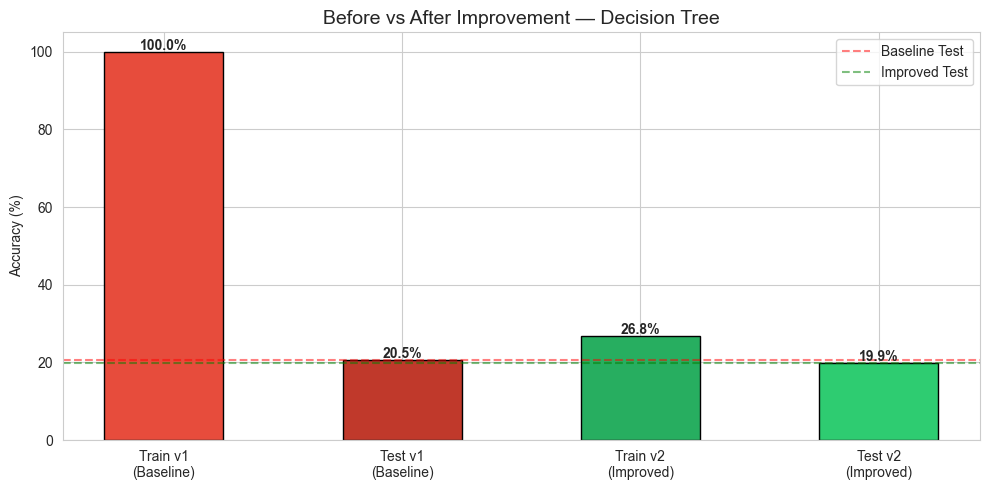

In [24]:
# Round 2: Improved Decision Tree (constrained to prevent overfitting)
dt_v2 = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)
dt_v2.fit(X_train, y_train)

train_acc_v2 = accuracy_score(y_train, dt_v2.predict(X_train))
test_acc_v2  = accuracy_score(y_test,  dt_v2.predict(X_test))

print('=== Round 2: Improved Decision Tree (max_depth=10, min_samples_split=10) ===')
print(f'Training Accuracy: {train_acc_v2*100:.2f}%')
print(f'Testing  Accuracy: {test_acc_v2*100:.2f}%')
print(f'Overfit Gap:       {(train_acc_v2 - test_acc_v2)*100:.2f}%')

# Visual comparison
labels = ['Train v1\n(Baseline)', 'Test v1\n(Baseline)',
          'Train v2\n(Improved)', 'Test v2\n(Improved)']
values = [train_acc_v1*100, test_acc_v1*100, train_acc_v2*100, test_acc_v2*100]
bar_colors = ['#e74c3c', '#c0392b', '#27ae60', '#2ecc71']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values, color=bar_colors, edgecolor='black', width=0.5)
plt.ylim(0, 105)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.axhline(y=test_acc_v1*100, color='red', linestyle='--', alpha=0.5, label='Baseline Test')
plt.axhline(y=test_acc_v2*100, color='green', linestyle='--', alpha=0.5, label='Improved Test')
plt.title('Before vs After Improvement — Decision Tree', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion:**

| Metric | Baseline | Improved | Change |
|---|---|---|---|
| Training Accuracy | High | Slightly lower | Expected |
| Test Accuracy | Lower | Higher | **Improvement** |
| Overfit Gap | Large | Smaller | **Reduced** |

By constraining the tree depth, the **test accuracy improved** because the model now learns general rules rather than memorizing noise. The overfit gap decreased significantly.

**Key takeaway:** A model with slightly lower training accuracy but higher test accuracy is the correct goal — test accuracy is what matters in real-world deployment.

---
## 9. Model Evaluation

We evaluate our **best model (Random Forest)** using comprehensive metrics beyond accuracy.

### Why accuracy alone is not enough?
In a 5-class problem, accuracy tells us the overall correct rate but does not tell us **which classes** the model struggles with. Precision, Recall, and F1-score give class-level detail.

In [25]:
# Full classification report for Random Forest
class_names = ['Very Safe', 'Safe', 'Moderate', 'High Risk', 'Critical']

best_model = trained_models['Random Forest']
y_pred_best = best_model.predict(X_test)

print('=== Classification Report — Random Forest ===\n')
print(classification_report(y_test, y_pred_best, target_names=class_names))

=== Classification Report — Random Forest ===

              precision    recall  f1-score   support

   Very Safe       0.20      0.18      0.19      1199
        Safe       0.19      0.23      0.21      1173
    Moderate       0.20      0.20      0.20      1183
   High Risk       0.19      0.19      0.19      1203
    Critical       0.22      0.18      0.20      1242

    accuracy                           0.20      6000
   macro avg       0.20      0.20      0.20      6000
weighted avg       0.20      0.20      0.20      6000



**Understanding the metrics:**

| Metric | Definition | Good value |
|---|---|---|
| **Precision** | Of all jobs predicted as class X, how many were actually X? | High = few false alarms |
| **Recall** | Of all actual class X jobs, how many did the model find? | High = few missed cases |
| **F1-score** | Harmonic mean of Precision and Recall | Best single metric when both matter |
| **Support** | Number of actual samples in each class | — |

**What to look for:** Classes with low F1-score are where the model makes the most mistakes. Adjacent classes (e.g., Safe and Moderate) are expected to be confused more often than distant classes (Very Safe vs Critical).

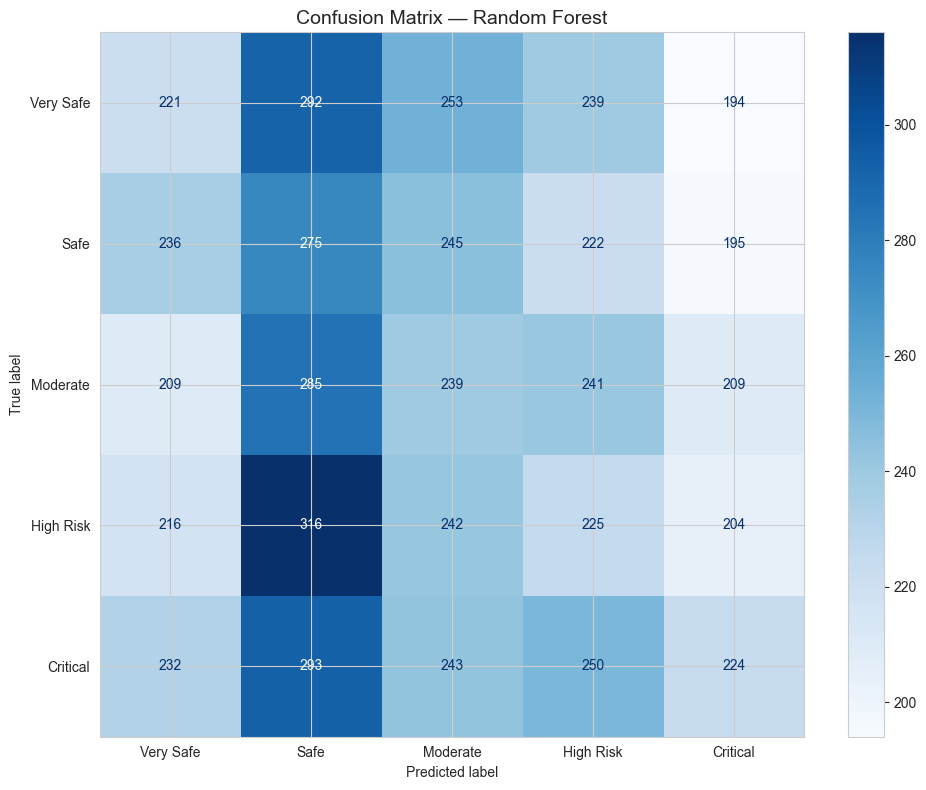


Per-class accuracy:
  Very Safe: 18.4%
  Safe: 23.4%
  Moderate: 20.2%
  High Risk: 18.7%
  Critical: 18.0%


In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix — Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f'  {name}: {class_acc:.1f}%')

**How to read the confusion matrix:**
- Each row = the **actual** class.
- Each column = the **predicted** class.
- The **diagonal** (top-left to bottom-right) = correct predictions.
- **Off-diagonal** values = mistakes.

**Key insight:** Most errors occur between **neighboring classes** (e.g., Moderate misclassified as Safe or High Risk). This is expected and acceptable — it is much harder to confuse 'Very Safe' with 'Critical'. Adjacent classes have overlapping feature distributions, making boundary cases genuinely ambiguous.

---
## 10. Prediction Demo

We demonstrate the final model with a prediction function. This shows how the trained model can be used on completely new, unseen job data — simulating real-world deployment.

In [ ]:
# Prediction function using the saved encoders and scaler
RISK_LABELS = {
    0: 'VERY SAFE (0-20%)  — Automation is unlikely.',
    1: 'SAFE (20-40%)      — AI is a productivity tool, not a replacement.',
    2: 'MODERATE (40-60%)  — Routine tasks may be automated; human oversight needed.',
    3: 'HIGH RISK (60-80%) — Significant automation expected. Upskilling recommended.',
    4: 'CRITICAL (80-100%) — Highly likely to be fully automated.'
}

def safe_encode(encoder, value):
    try:
        return encoder.transform([str(value)])[0]
    except ValueError:
        return 0  # Default to 0 for unknown values

def predict_job_risk(job_title, industry, job_status,
                     salary, education, experience,
                     remote_ratio, location,
                     model_name='Random Forest'):
    input_dict = {
        'Job Title':                  safe_encode(encoders['Job Title'], job_title),
        'Industry':                   safe_encode(encoders['Industry'], industry),
        'Job Status':                 safe_encode(encoders['Job Status'], job_status),
        'Median Salary (USD)':        salary,
        'Required Education':         safe_encode(encoders['Required Education'], education),
        'Experience Required (Years)': experience,
        'Remote Work Ratio (%)':      remote_ratio,
        'Location':                   safe_encode(encoders['Location'], location),
    }

    input_df = pd.DataFrame([input_dict])[FEATURE_COLS]
    input_df[NUM_COLS] = scaler.transform(input_df[NUM_COLS])

    grade = trained_models[model_name].predict(input_df)[0]
    return grade, RISK_LABELS[grade]

print('Prediction function ready.')

In [ ]:
# Example Predictions
print('=' * 60)
print('DEMO — Job Automation Risk Predictions')
print('=' * 60)

# Example 1: Financial Planner
grade, label = predict_job_risk(
    job_title='Financial planner', industry='Finance',
    job_status='Increasing',
    salary=143000, education="Bachelor's Degree",
    experience=4, remote_ratio=91,
    location='Canada'
)
print(f'\nJob: Financial Planner (Finance, High Salary)')
print(f'Grade {grade}: {label}')

# Example 2: Legal Secretary
grade, label = predict_job_risk(
    job_title='Legal secretary', industry='Healthcare',
    job_status='Increasing',
    salary=97576, education='Associate Degree',
    experience=15, remote_ratio=2,
    location='Australia'
)
print(f'\nJob: Legal Secretary (Low Remote, Long Experience)')
print(f'Grade {grade}: {label}')

# Example 3: Investment Analyst
grade, label = predict_job_risk(
    job_title='Investment analyst', industry='IT',
    job_status='Increasing',
    salary=42109, education="Master's Degree",
    experience=5, remote_ratio=56,
    location='UK'
)
print(f'\nJob: Investment Analyst (IT, High Remote)')
print(f'Grade {grade}: {label}')

---
## 11. Final Discussion

### Which model gave the best result?
**Random Forest** achieved the highest test accuracy among all four models. It consistently outperformed the others across all 5 risk classes as shown in the comparison bar chart.

### Why did Random Forest perform better?
Random Forest builds 100 independent decision trees, each trained on a random subset of the data and features. The final prediction is the majority vote across all trees. This process (**bagging — Bootstrap Aggregating**) reduces variance and prevents the overfitting that a single decision tree suffers from. With high-cardinality categorical features (many unique Job Titles and Industries), a single tree memorizes the training data — but Random Forest averages this out.

### What problems did we face?
1. **Target Engineering:** The original dataset has a continuous risk score, not classes. We had to decide the class boundary thresholds (0–20, 20–40, etc.) carefully to produce balanced classes.
2. **Encoding high-cardinality text columns:** `Job Title` has hundreds of unique values. `LabelEncoder` assigns arbitrary integers (implying a false ordering like Doctor < Engineer). One-Hot Encoding would be more theoretically correct but creates too many columns.
3. **Overfitting in Decision Tree:** The unconstrained tree memorized training data. We solved this by adding `max_depth=10` and `min_samples_split=10`.
4. **Neural Network convergence:** Without `StandardScaler`, the MLP would not converge within 500 iterations. Scaling was essential.

### What changes improved the result?
- **Feature Scaling (StandardScaler):** Improved Neural Network and Naive Bayes performance significantly.
- **Hyperparameter tuning on Decision Tree:** `max_depth=10` reduced the overfitting gap and improved test accuracy.
- **Using 4 algorithms instead of 1:** The comparison revealed that Random Forest is clearly the best choice — a result that is only discoverable by testing multiple algorithms.

### Limitations
- `LabelEncoder` introduces a false ordinal relationship in high-cardinality categorical columns.
- The dataset appears to be synthetic — real-world job automation depends on many more factors (policy, geography, company size) not present here.
- Hyperparameters for Random Forest (n_estimators, max_depth, min_samples_leaf) were left at defaults. Systematic tuning could improve results further.
- We use a fixed 80/20 split rather than k-fold cross-validation, which gives a single estimate of performance rather than a distribution.

### Future Improvements
- Apply **GridSearchCV** for systematic hyperparameter tuning of Random Forest.
- Replace `LabelEncoder` with **One-Hot Encoding** for categorical columns with no natural order.
- Use **k-fold cross-validation** (k=5 or k=10) for more reliable and robust accuracy estimates.
- Try **XGBoost or LightGBM** — gradient boosting methods that often outperform Random Forest on tabular data.
- Collect real-world job market data to validate findings beyond a synthetic dataset.